<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/raw/master/imgs/banner_IA.png"  width="1000px" height="250px">

# Machine learning: Gaussian Naive Bayes and classification metrics

This notebook is a **guided introduction to binary classification** with **Gaussian Naive Bayes (GNB)**. It moves from the probabilistic idea behind the model to a small **from-scratch implementation**, a **scikit-learn** baseline, and **rigorous evaluation** (cross-validation, sensitivity/specificity, and a full classification report). A closing section uses the **Breast Cancer Wisconsin** dataset for visualization and suggested follow-up exercises.

## Outline

1. [**Naive Bayes in depth**](#eje1)
2. [**Metrics and evaluation on classification**](#eje2)
3. **Extension — breast cancer dataset (exploration and exercises)**

In [1]:
#@title **Execute this cell**
#@markdown Please include your student id
import sys
import inspect

group_id = "IA1-20261-C2" #@param {type:"string"}
assignment_id = group_id +'.machine_learning'
student_id = "2225001" #@param {type:"string"}
"""
Put your student ID here

Example: student_id =  '2152145'
"""

"\nPut your student ID here\n\nExample: student_id =  '2152145'\n"

In [2]:
#@title **Execute this cell**
#@markdown **UTILS**
#@markdown Please dont modify any line in this cell

import os
import json
import requests
from collections import namedtuple


Config = namedtuple('Config', ['server_name'])
config = Config(server_name='https://bivlabgrader.azurewebsites.net/api')


def check_solution_and_evaluate(assignment_id: str, student_func_str: str):

    # Set the endpoint and payload.
    payload = {
        'func_str': student_func_str,
        'assignment_id': assignment_id,
        'student_id': student_id
    }
    endpoint_url = config.server_name + '/CheckAndEvaluateSolution'
    # print(endpoint_url)

    # Make request to server with the data coming from the notebook.
    r = requests.post(endpoint_url, params=payload)
    pprint_json_response(r.json())
    return r


def pprint_json_response(response, indent=0):
    """Pretty print the response."""
    for key, value in response.items():
        print('\t' * indent + str(key.capitalize()))

        # If dictionary, do a recurrent call.
        if isinstance(value, dict):
            pprint_json_response(value, indent + 1)
        else:
            # Enumerate elements if list.
            if isinstance(value, list):
                if len(value) == 1:
                    print('\t' * (indent + 1) + str(value[0]))
                else:
                    for i, e in enumerate(value, start=1):
                        print('\t' * (indent + 1) + f'{i}. {e}')
            else:
                print('\t' * (indent + 1) + str(value))

In [3]:
#@title **MONTAR EL DRIVE** { display-mode: "form" }
import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/My Drive/IA-1-UIS/')
print(os.getcwd())

Mounted at /content/drive
/content/drive/My Drive/IA-1-UIS


In [4]:
#@title 2. **LOAD LIB** { display-mode: "form" }
from __future__ import division, print_function, unicode_literals #py2 and py3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
sns.set_theme()
from sklearn.model_selection import KFold
from sklearn.metrics import *

*Scope:* This walkthrough uses **tabular features** and Gaussian Naive Bayes; it does not cover text or clinical-notes NLP, even if the filename suggests a classification theme.*

### How to read this notebook

**What it does.** You will work through Gaussian Naive Bayes end-to-end: load a two-class dataset, build priors and per-class Gaussian likelihoods under the naive independence assumption, train both a custom GNB and `sklearn.naive_bayes.GaussianNB`, and evaluate with train/test splits, k-fold cross-validation, and several classification metrics.

**Problem it addresses.** For labeled training data with continuous features, we want (i) a principled way to score new points for class 0 vs. class 1 using Bayes’ rule, and (ii) evaluation that goes beyond a single accuracy number—especially how often each class is predicted correctly.

**Structure.** **Setup** — identifiers and course utilities (optional), optional Colab Drive mount, and scientific libraries. **Theory** — Bayes rule, priors, and Gaussian class-conditional likelihoods. **Practice (banknotes)** — data inspection, scratch GNB, sklearn GNB. **Evaluation** — k-fold, class-specific rates (TPR/TNR), classification report. **Extension** — breast cancer scatter plot and prompts for further experiments.

*If you run outside Google Colab, skip Drive mounting and point the banknote path to your local `data/` directory.*

## 1. Naive Gaussian Bayes in depth <a name="eje1"></a>

For a new sample $x$ whose class is unknown, Naive Bayes assigns the class with **largest posterior** $P(c \mid x)$.

**Decision rule.** Compare $P(0\mid x)$ and $P(1\mid x)$; predict the class with the higher value.

**Bayes’ perspective.** Before observing $x$, we encode **priors** $P(0)$ and $P(1)$. After observing $x$, we update using **likelihoods** $P(x\mid c)$:

$$P(0|x) = \frac{P(x|0) P(0)}{P(x)} \qquad P(1|x) = \frac{P(x|1) P(1)}{P(x)}$$

- $P(0)$, $P(1)$: class frequencies in the training data (empirical priors).
- $P(x\mid 0)$, $P(x\mid 1)$: how plausible the features are under each class. We choose a **model** for these densities.
- $P(x)$: identical when comparing the two posteriors as a ratio, so we often absorb it into a **proportionality** constant and compare scores that need not normalize over all $x$.

**How to compute the pieces.**

- **Priors** $P(c)$: relative frequency of each class in the training set.
- **Likelihoods** $P(x\mid c)$: for continuous features, we **assume** each **class-conditional** distribution is **Gaussian**, and estimate means and variances from data. **Naive** means features are modeled as **conditionally independent** given the class, so the joint likelihood factorizes into a product of univariate Gaussian factors (one per feature).
- Each class therefore has a mean vector and variance vector (per feature), fit from the training points with that label.

**Next.** We turn these ingredients into **empirical PDFs** per class on a real dataset.

### From equations to code

The implementation below **estimates** one Gaussian per feature per class from the training split, then **predicts** by maximizing **log** posterior (log-prior plus sum of log-likelihoods) to reduce numeric underflow when multiplying many small probabilities.

### Conceptual checklist (see also course notes)

<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-2-uis-student/-/raw/master/imgs/icon1.png" width="200">

- Why is the model called **naive**?
- Why **Gaussian** Naive Bayes specifically?
- How does the independence assumption interact with multiple features?

### Why use Gaussian Naive Bayes?

- **Small-sample friendly:** only class priors and per-class means and variances must be estimated.
- **Interpretability:** under the naive factorization, each feature contributes additively in log-space to the class score.
- **No full covariance per class:** cost grows linearly with the number of features, not quadratically.

### Dataset: banknote authentication

We use the **UCI banknote authentication** dataset: four continuous statistics derived from wavelet-transformed banknote images and a binary authenticity label.

**Inputs:** variance, skewness, curtosis, and entropy (continuous). **Target:** forged vs. genuine (integer class).

The next cell **loads** the file and shows **pairwise scatter and histograms** stratified by class.

#### Data loading and exploratory views

The notebook expects `data/data_banknote_authentication.txt.gz` (adjust the path if your copy lives elsewhere). The code builds `X` (features) and `y` (labels), prints shapes, and draws a **pair plot** to visualize separation between classes in 2D projections.

(1372, 5)
(1372, 4) (1372,)


,varwt,skewt,curwt,entrwt,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


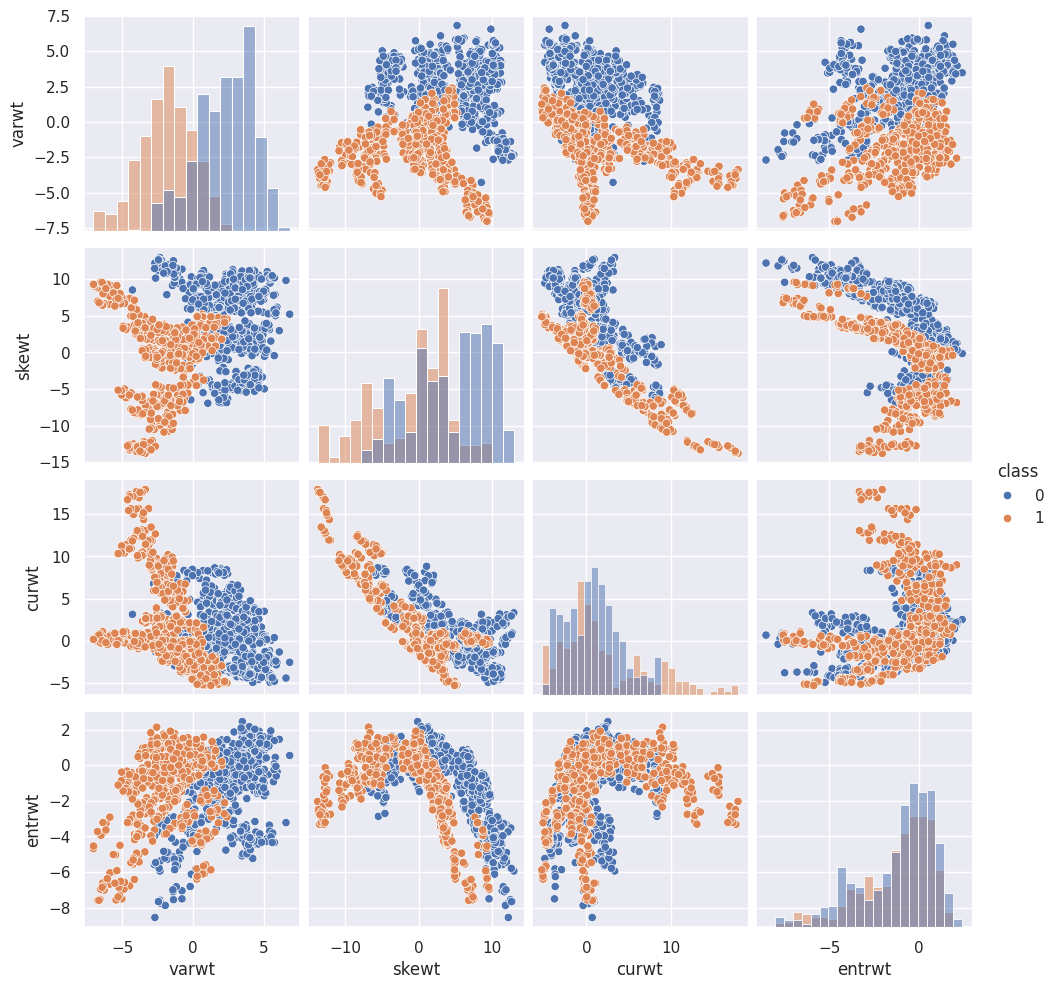

In [5]:
#@title **code** To read the dataset
d = pd.read_csv("data/data_banknote_authentication.txt.gz")
print(d.shape)
X = d.values[:,:-1]
y = d.values[:,-1]
sns.pairplot(d, hue="class", diag_kind="hist");# kind="kde"
print(X.shape, y.shape)
d.head()

#### Gaussian Naive Bayes from scratch

The class below implements **fit** (per-class means, variances, priors) and **predict** (argmax over log posteriors). Run it and compare the printed accuracy to **`sklearn`** in the next subsection.

In [6]:
import numpy as np

class GaussianNaiveBayes:
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        n_classes = len(self.classes)

        # Inicializar vectores para la media, varianza y probabilidad a priori (priors)
        self.mean = np.zeros((n_classes, n_features), dtype=np.float64)
        self.var = np.zeros((n_classes, n_features), dtype=np.float64)
        self.priors = np.zeros(n_classes, dtype=np.float64)

        # Calcular la media, varianza y prior para cada clase
        for idx, c in enumerate(self.classes):
            X_c = X[y == c] #Separando elementos que peritenecen a la clase C
            self.mean[idx, :] = X_c.mean(axis=0)
            self.var[idx, :] = X_c.var(axis=0)
            self.priors[idx] = X_c.shape[0] / float(n_samples)

    def predict(self, X):
        y_pred = [self._predict(x) for x in X]
        return np.array(y_pred)

    def _predict(self, x):
        posteriors = []

        # Calcular la probabilidad posterior para cada clase
        for idx, c in enumerate(self.classes):
            # Usamos logaritmos para evitar el desbordamiento aritmético (underflow) con números muy pequeños
            prior = np.log(self.priors[idx])
            posterior = np.sum(np.log(self._pdf(idx, x)))
            posterior = prior + posterior
            posteriors.append(posterior)

        # Devolver la clase con la mayor probabilidad posterior
        return self.classes[np.argmax(posteriors)]

    def _pdf(self, class_idx, x):
        """Calcula la Función de Densidad de Probabilidad (PDF) Gaussiana"""
        mean = self.mean[class_idx]
        var = self.var[class_idx]
        numerator = np.exp(-((x - mean) ** 2) / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=25)

# Entrenar y predecir con nuestra implementación
nb = GaussianNaiveBayes()
nb.fit(X_train, y_train)
predicciones = nb.predict(X_test)

print(f"Precisión del modelo desde cero: {accuracy_score(y_test, predicciones):.4f}")

Precisión del modelo desde cero: 0.8617


In [ ]:
nb.var, nb.mean, nb.priors

(array([[ 3.98854986, 26.68522659,  9.97548375,  4.46491058],
        [ 3.53729023, 29.12972965, 28.31465281,  4.20050894]]),
 array([[ 2.27203409,  4.21843505,  0.81253662, -1.13066757],
        [-1.85662048, -0.93471749,  2.11909638, -1.23348561]]),
 array([0.54895833, 0.45104167]))

In [ ]:
nb.var, nb.mean, nb.priors

(array([[ 4.0324199 , 25.65846444, 10.45710966,  4.46495594],
        [ 3.88202918, 29.42004952, 28.22701666,  4.61132007]]),
 array([[ 2.28707232,  4.30600769,  0.79085666, -1.13638687],
        [-1.80442694, -0.93756398,  2.08183039, -1.29427704]]),
 array([0.559375, 0.440625]))

#### `sklearn` Gaussian Naive Bayes (baseline)

The same **train/test split** (`test_size=0.3`, `random_state=21`) is used for **`GaussianNB`**. The printed accuracy should align closely with the from-scratch model if both use the same split and modeling assumptions.

In [7]:
#@title  **code** Typical split. Is it sufficient?
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=25)
est = GaussianNB()

est.fit(X_train,y_train)
print("%.3f"%accuracy_score(est.predict(X_test), y_test))

0.862


## 2. Metrics and evaluation on classification <a name="eje2"></a>

A single holdout accuracy can be optimistic or unstable. **K-fold cross-validation** retrains and re-evaluates on different train/validation partitions so we report **mean and standard deviation** of the score across folds.

<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/raw/master/imgs/kfold.jpg" style="width:400px;">

*Illustration: each fold acts as a validation set once; the rest of the data train the model.*

**Next cell:** 10-fold cross-validation with **`KFold(..., shuffle=True)`** and accuracy as the scoring function.

In [8]:
#@title **code:** cross-validation
s = cross_val_score(est, X, y, cv=KFold(10, shuffle=True), scoring=make_scorer(accuracy_score))
print (s)
print ("accuracy %.3f (+/- %.5f)"%(np.mean(s), np.std(s)))

[0.82608696 0.86231884 0.80291971 0.7810219  0.84671533 0.86131387
 0.81751825 0.84671533 0.8540146  0.89051095]
accuracy 0.839 (+/- 0.03055)


### Class-specific rates: TPR and TNR

Accuracy alone can hide imbalance between classes. Two common **per-class** summaries:

- **TPR (true positive rate, sensitivity):** among points with true label 1, the fraction predicted as 1 — “how well we find the positive class.”
- **TNR (true negative rate, specificity):** among points with true label 0, the fraction predicted as 0 — “how well we reject the negative class.”

**Confusion-matrix language (binary case):**

| | Predicted positive | Predicted negative |
|--|--|--|
| **Actual positive** | True positive (TP) | False negative (FN) |
| **Actual negative** | False positive (FP) | True negative (TN) |

The next cell defines **`tpr`** and **`tnr`** scorers compatible with `cross_val_score`; the following cell applies them to the same 10-fold setup as accuracy.

In [ ]:
#@title **code** other metrics
def tpr(est,X,y):
    p = est.predict(X)
    return np.mean (p[y==1] == y[y==1])

def tnr(est,X,y):
    p = est.predict(X)
    return np.mean(p[y==0] == y[y==0])

In [ ]:
#@title **code** we can obtain performance with different metrics
s = cross_val_score(est, X, y, cv=KFold(10, shuffle=True), scoring=tpr)
print ("tpr %.3f (+/- %.5f)"%(np.mean(s), np.std(s)))
s = cross_val_score(est, X, y, cv=KFold(10, shuffle=True), scoring=tnr)
print ("tnr %.3f (+/- %.5f)"%(np.mean(s), np.std(s)))

tpr 0.789 (+/- 0.02963)
tnr 0.877 (+/- 0.03121)


### Full classification report (`sklearn`)

`classification_report` aggregates **precision**, **recall** (same as TPR for the positive class in binary problems), and **F1** per class, plus micro/macro averages depending on configuration. The next cell retrains `GaussianNB` on a train split and prints the report on the held-out test set.

In [ ]:
#@title **code** classification report
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=21)
est = GaussianNB()

est.fit(X_train,y_train)
y_pred = est.predict(X_test)
print(classification_report(y_test, y_pred))

### Discussion prompts

<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-2-uis-student/-/raw/master/imgs/icon1.png" width="200">

- How do **precision**, **recall**, and **F1** differ from raw accuracy?
- When would you prioritize precision vs. recall?
- How might conclusions change on a **heavily imbalanced** dataset?

### Extension: Breast Cancer Wisconsin dataset

<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-2-uis-student/-/raw/master/imgs/icon1.png" width="200">

Suggested tasks:

- Load data with `from sklearn.datasets import load_breast_cancer`.
- Train a classifier with a fixed **80/20** train/test split.
- Compare with **10-fold** cross-validation.
- For small samples, consider **leave-one-out** (`sklearn.model_selection.LeaveOneOut`) and discuss cost vs. variance of the estimate.

The next cell builds a **relational scatter plot** (hue = diagnosis, size encodes a third feature) for interactive exploration via the Colab form widgets.

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0.0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0.0


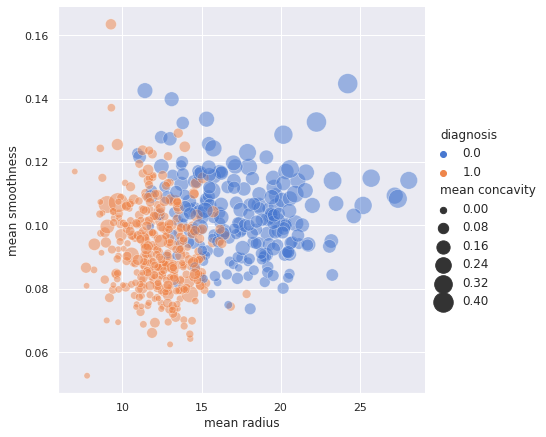

In [ ]:
#@title **Breast cancer dataset**
variable_x = "mean radius" #@param {type:"string"}
variable_y = "mean smoothness" #@param {type:"string"}
variable_s = "mean concavity" #@param {type:"string"}


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
sns.set_theme()


cancer = load_breast_cancer()
data_bc = pd.DataFrame(np.c_[cancer['data'], cancer['target']],
                  columns= np.append(cancer['feature_names'], ['diagnosis']))
sns.relplot(x=variable_x, y=variable_y, hue="diagnosis", size=variable_s,
            sizes=(40, 400), alpha=.5, palette="muted",
            height=6, data=data_bc)

data_bc.head(2)

#### Exercise (student code cell)

Use the cell below for **your own experiments** (e.g., alternative features, metrics, or models) without altering the graded cells above unless the assignment allows it.

In [ ]:
#@title **code student**




## References

1. K-fold cross-validation (tutorial): https://machinelearningmastery.com/k-fold-cross-validation/
2. Titanic competition (example binary classification task): https://www.kaggle.com/c/titanic
3. Sensitivity and specificity: https://en.wikipedia.org/wiki/Sensitivity_and_specificity

---

<img src="https://gitlab.com/bivl2ab/academico/cursos-uis/ai/ai-uis-student/raw/master/imgs/bannerThanks.jpg" alt="Thanks" style="width:700px;">

*End of notebook.*